In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 18.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.0 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 30.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.2 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 82.4 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pylibcugraph-cu12 24.12.0 requires pylibraft-cu12==24.12.*, but you have pylibraft-cu12 25.2.0 whic

In [12]:
import glob
import os
import matplotlib.pyplot as plt
from ultralytics import YOLO

In [6]:
classes = [0] * 4

files = glob.glob("/kaggle/input/object-detection-wildlife-dataset-yolo-format/final_data/train/labels/*.txt")
for txt_file_path in files:
    with open(txt_file_path) as f:
        strings = f.readlines()
        for string in strings:
            string = string.strip().split(" ")
            classes[int(string[0])] += 1
classes


[447, 603, 445, 662]

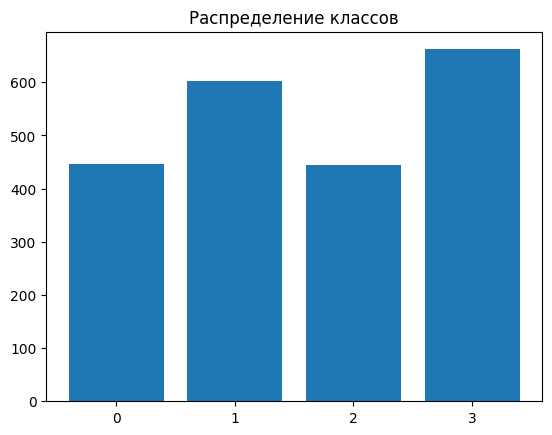

In [7]:
names = [str(idx) for idx in range(4)]
plt.bar(names, classes)
plt.title("Распределение классов")
plt.show()

In [15]:
model = YOLO("yolo11s.pt")
data_yaml_path = "/kaggle/input/custom-yaml-2/dataset.yaml"

In [16]:
results = model.train(data=data_yaml_path, epochs=100, 
                      imgsz=640, 
                      plots=True, 
                      device=0)

Ultralytics 8.3.119 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolo11s.pt, data=/kaggle/input/custom-yaml-2/dataset.yaml, epochs=100, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=None, name=train4, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, show_boxes=True

100%|██████████| 755k/755k [00:00<00:00, 16.8MB/s]


Overriding model.yaml nc=80 with nc=4

                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     26080  ultralytics.nn.modules.block.C3k2            [64, 128, 1, False, 0.25]     
  3                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
  4                  -1  1    103360  ultralytics.nn.modules.block.C3k2            [128, 256, 1, False, 0.25]    
  5                  -1  1    590336  ultralytics.nn.modules.conv.Conv             [256, 256, 3, 2]              
  6                  -1  1    346112  ultralytics.nn.modules.block.C3k2            [256, 256, 1, True]           
  7                  -1  1   1180672  ultralytics

100%|██████████| 5.35M/5.35M [00:00<00:00, 69.8MB/s]


AMP: checks passed ✅
train: Fast image access ✅ (ping: 1.1±1.7 ms, read: 22.8±14.2 MB/s, size: 207.6 KB)


...


100 epochs completed in 0.654 hours.
Optimizer stripped from runs/detect/train4/weights/last.pt, 19.2MB
Optimizer stripped from runs/detect/train4/weights/best.pt, 19.2MB

Validating runs/detect/train4/weights/best.pt...
Ultralytics 8.3.119 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11s summary (fused): 100 layers, 9,414,348 parameters, 0 gradients, 21.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 5/5 [00:02<00:00,  2.32it/s]


                   all        150        262      0.974      0.935      0.977      0.873
               buffalo         38         60       0.96        0.9      0.941      0.862
              elephant         43         83      0.987      0.939      0.991      0.836
                 rhino         42         58      0.978          1      0.995      0.939
                 zebra         28         61      0.972      0.902      0.981      0.855


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


Speed: 0.2ms preprocess, 4.5ms inference, 0.0ms loss, 3.0ms postprocess per image
Results saved to runs/detect/train4


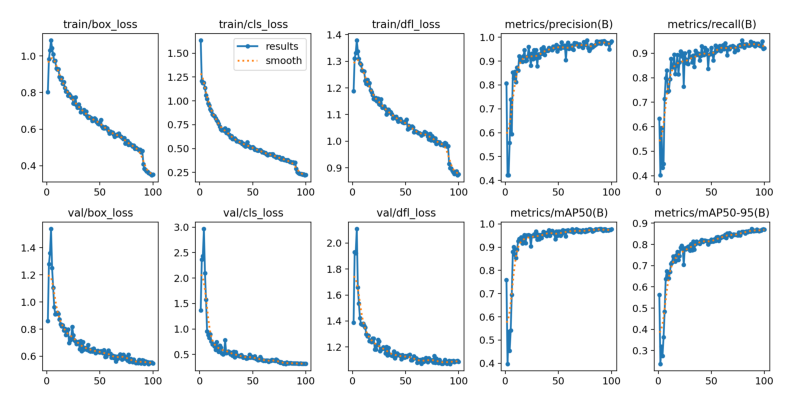

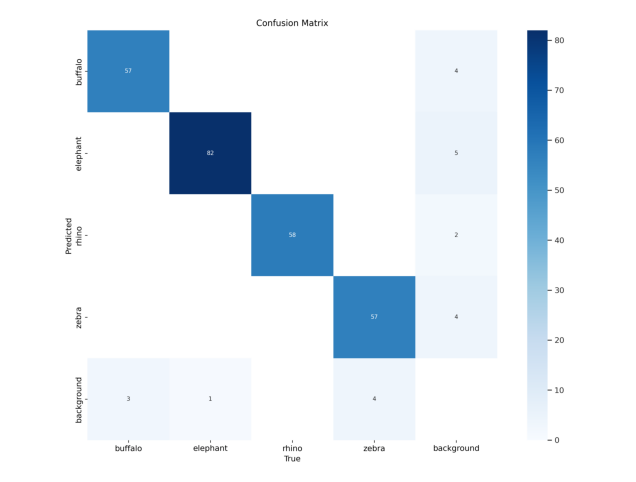

In [18]:
import matplotlib.pyplot as plt
from PIL import Image

plot_paths = [
    "/kaggle/working/runs/detect/train4/results.png",
    "/kaggle/working/runs/detect/train4/confusion_matrix.png"
]

for path in plot_paths:
    img = Image.open(path)
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

In [20]:
model_nano = YOLO("yolo11n.pt")

In [21]:
results_2 = model_nano.train(data=data_yaml_path, epochs=50, 
                      imgsz=640, 
                      plots=True, 
                      device=0)

Ultralytics 8.3.119 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolo11n.pt, data=/kaggle/input/custom-yaml-2/dataset.yaml, epochs=50, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=None, name=train5, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, show_boxes=True,

train: Scanning /kaggle/input/object-detection-wildlife-dataset-yolo-format/final_data/train/labels... 1203 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1203/1203 [00:01<00:00, 649.88it/s]


WARNING ⚠️ train: Cache directory /kaggle/input/object-detection-wildlife-dataset-yolo-format/final_data/train is not writeable, cache not saved.
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access ✅ (ping: 0.5±1.1 ms, read: 71.6±65.1 MB/s, size: 135.6 KB)


val: Scanning /kaggle/input/object-detection-wildlife-dataset-yolo-format/final_data/valid/labels... 150 images, 0 backgrounds, 0 corrupt: 100%|██████████| 150/150 [00:00<00:00, 376.56it/s]

WARNING ⚠️ val: Cache directory /kaggle/input/object-detection-wildlife-dataset-yolo-format/final_data/valid is not writeable, cache not saved.


...


50 epochs completed in 0.210 hours.
Optimizer stripped from runs/detect/train5/weights/last.pt, 5.5MB
Optimizer stripped from runs/detect/train5/weights/best.pt, 5.5MB

Validating runs/detect/train5/weights/best.pt...
Ultralytics 8.3.119 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,582,932 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 5/5 [00:01<00:00,  2.97it/s]


                   all        150        262      0.936      0.935      0.969      0.849
               buffalo         38         60      0.961      0.883      0.945      0.846
              elephant         43         83      0.886      0.976       0.98      0.828
                 rhino         42         58       0.95      0.978      0.989      0.913
                 zebra         28         61      0.946      0.902      0.962       0.81


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


Speed: 0.2ms preprocess, 2.0ms inference, 0.0ms loss, 3.3ms postprocess per image
Results saved to runs/detect/train5


In [25]:
results_3 = model_nano.train(data=data_yaml_path, epochs=50, 
                      imgsz=640, 
                      plots=True, 
                      device=0,
                          hsv_h=0.03, hsv_s=0.6, hsv_v=0.5, degrees=90, translate=0.25, shear=10, 
                           fliplr=0.9)

Ultralytics 8.3.119 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolo11n.pt, data=/kaggle/input/custom-yaml-2/dataset.yaml, epochs=50, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=None, name=train52, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, show_boxes=True

train: Scanning /kaggle/input/object-detection-wildlife-dataset-yolo-format/final_data/train/labels... 1203 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1203/1203 [00:01<00:00, 701.05it/s]

WARNING ⚠️ train: Cache directory /kaggle/input/object-detection-wildlife-dataset-yolo-format/final_data/train is not writeable, cache not saved.


albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access ✅ (ping: 0.9±1.9 ms, read: 80.4±61.3 MB/s, size: 135.6 KB)


val: Scanning /kaggle/input/object-detection-wildlife-dataset-yolo-format/final_data/valid/labels... 150 images, 0 backgrounds, 0 corrupt: 100%|██████████| 150/150 [00:00<00:00, 464.50it/s]

...


50 epochs completed in 0.214 hours.
Optimizer stripped from runs/detect/train52/weights/last.pt, 5.5MB
Optimizer stripped from runs/detect/train52/weights/best.pt, 5.5MB

Validating runs/detect/train52/weights/best.pt...
Ultralytics 8.3.119 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,582,932 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 5/5 [00:01<00:00,  2.93it/s]


                   all        150        262       0.92      0.952      0.975      0.779
               buffalo         38         60      0.933       0.93      0.975      0.802
              elephant         43         83      0.897      0.941      0.967      0.738
                 rhino         42         58      0.948          1      0.993      0.842
                 zebra         28         61        0.9      0.934      0.966      0.733


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


Speed: 0.2ms preprocess, 2.4ms inference, 0.0ms loss, 2.9ms postprocess per image
Results saved to runs/detect/train52


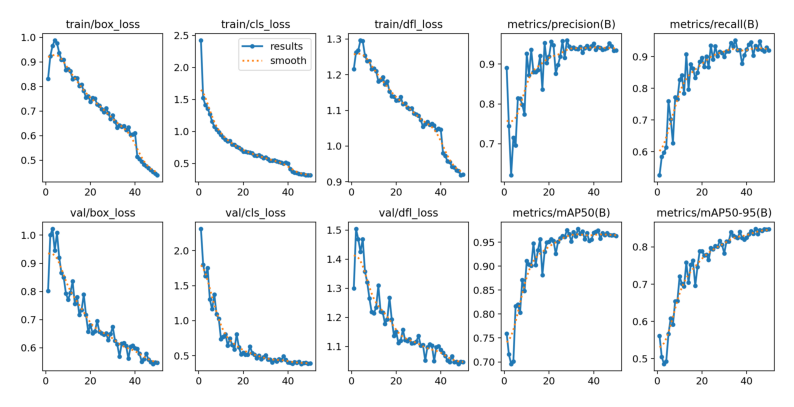

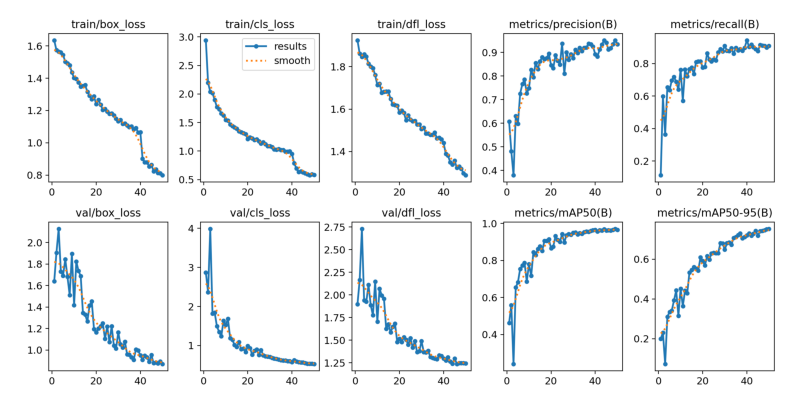

In [36]:
plot_paths = [
    "/kaggle/working/runs/detect/train5/results.png",
    "/kaggle/working/runs/detect/train6/results.png"
]

for path in plot_paths:
    img = Image.open(path)
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

In [29]:
model_nano_2 = YOLO("yolo11n.pt")

In [32]:
results_3 = model_nano_2.train(data=data_yaml_path, epochs=50, 
                      imgsz=640, 
                      plots=True, 
                      device=0,
                          hsv_h=0.03, hsv_s=0.6, hsv_v=0.5, degrees=90, translate=0.25, shear=20, 
                           fliplr=0.9)

Ultralytics 8.3.119 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolo11n.pt, data=/kaggle/input/custom-yaml-2/dataset.yaml, epochs=50, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=None, name=train6, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, show_boxes=True,

train: Scanning /kaggle/input/object-detection-wildlife-dataset-yolo-format/final_data/train/labels... 1203 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1203/1203 [00:01<00:00, 787.30it/s]

WARNING ⚠️ train: Cache directory /kaggle/input/object-detection-wildlife-dataset-yolo-format/final_data/train is not writeable, cache not saved.
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


val: Fast image access ✅ (ping: 0.3±0.4 ms, read: 96.3±54.5 MB/s, size: 135.6 KB)


val: Scanning /kaggle/input/object-detection-wildlife-dataset-yolo-format/final_data/valid/labels... 150 images, 0 backgrounds, 0 corrupt: 100%|██████████| 150/150 [00:00<00:00, 447.24it/s]

...


50 epochs completed in 0.216 hours.
Optimizer stripped from runs/detect/train6/weights/last.pt, 5.5MB
Optimizer stripped from runs/detect/train6/weights/best.pt, 5.5MB

Validating runs/detect/train6/weights/best.pt...
Ultralytics 8.3.119 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,582,932 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 5/5 [00:02<00:00,  2.09it/s]


                   all        150        262      0.934      0.909      0.966      0.753
               buffalo         38         60      0.922      0.867      0.965      0.759
              elephant         43         83      0.908      0.904      0.956      0.728
                 rhino         42         58      0.974      0.983      0.993      0.825
                 zebra         28         61      0.931      0.884      0.948      0.698


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


Speed: 0.2ms preprocess, 2.0ms inference, 0.0ms loss, 4.8ms postprocess per image
Results saved to runs/detect/train6


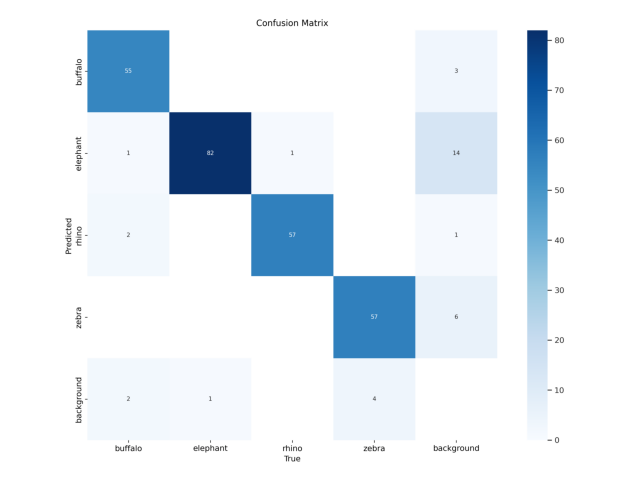

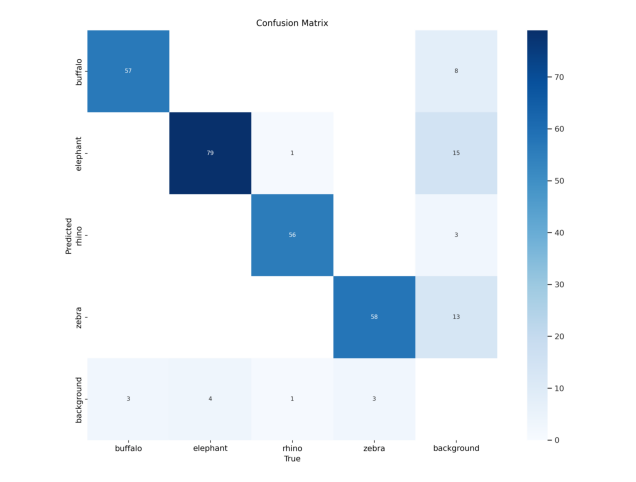

In [35]:
plot_paths = [
    "/kaggle/working/runs/detect/train5/confusion_matrix.png",
    "/kaggle/working/runs/detect/train522/confusion_matrix.png"
]

for path in plot_paths:
    img = Image.open(path)
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.show()